# Milestone 2 — the lake mask: what it changed

Section 10 of `m2_hex_table.ipynb` found that 25 of the top 40 hexes were lake hexes, 6.5 times the
city-wide rate, because rule C missed lakes that sit under weed or are dry for part of the run.
Decided on 2026-09-23:

1. **Mask mapped water at the pixel level.** Every pixel inside an OSM lake, pond, reservoir or
   sewage pond is dropped before a hex is averaged, the same pixels in every year
   (`measure_hexes.py --mask-water` → `results/m2_hex_table_masked.csv`). **Wetlands are kept**:
   their loss belongs in the story, and OSM maps them too patchily to mask consistently.
2. **Rule C is dropped.** The masked table is read with no hex-level water exclusion. One approach,
   not two.
3. **No minimum-land cutoff yet.** Section 5 only *measures* what a 25% cutoff would change, so the
   decision can be made from numbers.

The ranking is the same as section 10's: the 40 largest changes by **end-minus-start**, meaning
normalised 2026 minus normalised 2019, losses and gains both counted.

**No Earth Engine.** It reads the two hex tables, `results/m2_water_hexes.csv` (only to compare
against the old list), `data/hex_grid.geojson` and `data/osm_water.geojson`.

In [1]:
import os
from pathlib import Path

import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

METRIC = "EPSG:32643"
INK, MUTED, LOSS, GAIN = "#2b2b2b", "#8a8a8a", "#8c2d04", "#1b7837"
LAKE_CUTOFF = 0.10
LAND_CUTOFF = 0.25
TOP = 40

old = pd.read_csv("results/m2_hex_table.csv")
new = pd.read_csv("results/m2_hex_table_masked.csv")
rule_c = set(pd.read_csv("results/m2_water_hexes.csv").h3)
grid = gpd.read_file("data/hex_grid.geojson").to_crs(METRIC).set_index("h3")
osm = gpd.read_file("data/osm_water.geojson").to_crs(METRIC)

assert len(new) == len(old), f"masked table incomplete: {len(new):,} of {len(old):,} rows"

full_px = old.groupby("h3").n_pixels.median()
land = (new.groupby("h3").n_pixels.median() / full_px).rename("land")


def normalised(table, drop=()):
    g = table[~table.h3.isin(drop)].pivot(index="h3", columns="year", values="green").dropna()
    return g, g.sub(g.mean(axis=0), axis=1)


g_old, n_old = normalised(old, drop=rule_c)
g_new, n_new = normalised(new)
YEARS = list(g_new.columns)
ems_old = n_old[YEARS[-1]] - n_old[YEARS[0]]
ems_new = n_new[YEARS[-1]] - n_new[YEARS[0]]
rank_old = ems_old.abs().rank(ascending=False).astype(int)
rank_new = ems_new.abs().rank(ascending=False).astype(int)
top_old = ems_old.abs().nlargest(TOP).index
top_new = ems_new.abs().nlargest(TOP).index


def share_of(frame):
    pieces = gpd.overlay(grid.reset_index()[["h3", "geometry"]], frame[["geometry"]])
    return (pieces.dissolve(by="h3").area / grid.geometry.area).reindex(grid.index).fillna(0)


masked_share = share_of(osm[osm["class"] != "wetland"])
wetland_share = share_of(osm[osm["class"] == "wetland"])
any_share = share_of(osm)
named = (gpd.overlay(grid.reset_index()[["h3", "geometry"]], osm[["name", "geometry"]])
         .assign(area=lambda f: f.area).sort_values("area", ascending=False)
         .groupby("h3").name.apply(lambda s: next((n for n in s if n), "")))

print(f"old: {len(g_old):,} hexes (rule C removed {len(rule_c)})   new: {len(g_new):,} hexes "
      f"({len(grid) - len(g_new)} are all water, no land left)")

old: 2,818 hexes (rule C removed 50)   new: 2,868 hexes (0 are all water, no land left)


---
## 1 — What the mask removed

How much land each hex has left once mapped water is taken out. Most hexes lose nothing. The ones
that lose a lot are the lake hexes, which now count only their land part.

In [2]:
brackets = pd.cut(land, [-0.001, 0.05, 0.10, 0.25, 0.50, 0.90, 0.999, 1.001],
                  labels=["<5%", "5-10%", "10-25%", "25-50%", "50-90%", "90-99.9%", "untouched"])
print(brackets.value_counts().reindex(brackets.cat.categories).rename("hexes").to_string())
masked_km2 = ((1 - land) * grid.geometry.area).sum() / 1e6
print(f"\nland pixels removed: {masked_km2:.1f} km2 of {grid.geometry.area.sum() / 1e6:,.0f} km2")
print(f"rule C's {len(rule_c)} hexes: median land left {land[list(rule_c)].median():.0%}; "
      f"{(land[list(rule_c)] > 0.9).sum()} of them keep over 90% of their land "
      f"(water the satellite saw that OSM doesn't map)")

<5%             2
5-10%           1
10-25%          5
25-50%         21
50-90%        230
90-99.9%     1034
untouched    1575

land pixels removed: 74.2 km2 of 2,173 km2
rule C's 50 hexes: median land left 56%; 4 of them keep over 90% of their land (water the satellite saw that OSM doesn't map)


---
## 2 — Before and after, at the top of the ranking

The question section 10 asked, asked again. A *lake hex* is still a hex with at least 10% mapped
water in it. After the mask that water isn't measured, only the land around it, so a lake hex at the
top now means the land *beside* a lake changed, not the lake itself. The wetland line counts the one
kind of water that was deliberately left in.

In [3]:
def lake_rate(idx):
    return (any_share[idx] >= LAKE_CUTOFF).mean()


rows = {
    "all hexes": (lake_rate(g_new.index), (wetland_share[g_new.index] >= LAKE_CUTOFF).mean()),
    f"top {TOP} before the mask": (lake_rate(top_old), (wetland_share[top_old] >= LAKE_CUTOFF).mean()),
    f"top {TOP} after the mask": (lake_rate(top_new), (wetland_share[top_new] >= LAKE_CUTOFF).mean()),
}
summary = pd.DataFrame(rows, index=["lake hexes (any mapped water >= 10%)", "wetland >= 10%"]).T
print(summary.map("{:.1%}".format).to_string())
print(f"\nhexes in both top-{TOP} lists: {len(set(top_old) & set(top_new))} of {TOP}")
print(f"end-minus-start, before vs after, correlation over all hexes: "
      f"{ems_old.corr(ems_new.reindex(ems_old.index)):+.3f}")

                       lake hexes (any mapped water >= 10%) wetland >= 10%
all hexes                                             11.1%           1.8%
top 40 before the mask                                62.5%          17.5%
top 40 after the mask                                 47.5%          25.0%

hexes in both top-40 lists: 25 of 40
end-minus-start, before vs after, correlation over all hexes: +0.889


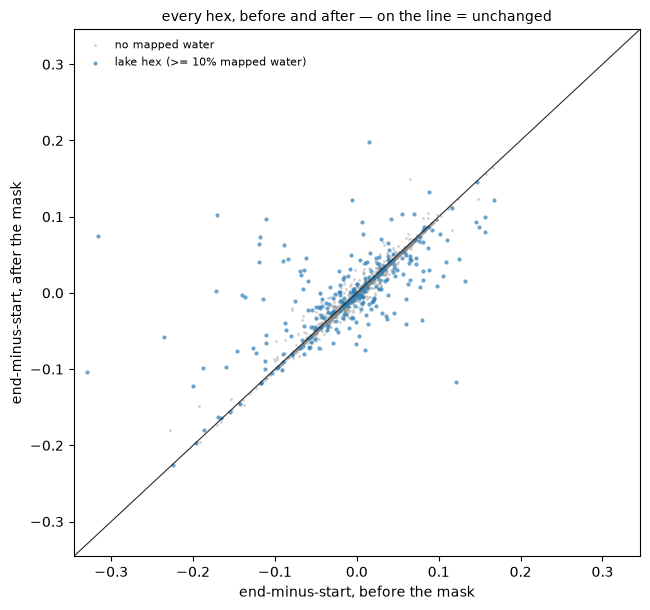

In [4]:
common = ems_old.index.intersection(ems_new.index)
fig, ax = plt.subplots(figsize=(6.6, 6.2))
lake = any_share[common] >= LAKE_CUTOFF
ax.scatter(ems_old[common][~lake], ems_new[common][~lake], s=4, color=MUTED, alpha=0.4, linewidths=0,
           label="no mapped water")
ax.scatter(ems_old[common][lake], ems_new[common][lake], s=9, color="#2c7fb8", alpha=0.7, linewidths=0,
           label=f"lake hex (>= {LAKE_CUTOFF:.0%} mapped water)")
lim = max(ems_old.abs().max(), ems_new.abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], color=INK, linewidth=0.8)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("end-minus-start, before the mask")
ax.set_ylabel("end-minus-start, after the mask")
ax.set_title("every hex, before and after — on the line = unchanged", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

---
## 3 — The new top 40

`old rank` is the hex's position before the mask (`-` if rule C had removed it). `land` is the share of
the hex still measured. `water nearby` is the largest named water body OSM maps in it.

In [5]:
top_table = pd.DataFrame({
    "rank": range(1, TOP + 1),
    "change": ems_new[top_new].round(3),
    "old rank": [str(rank_old[h]) if h in rank_old.index else "-" for h in top_new],
    "land": land[top_new].map("{:.0%}".format),
    "masked water": masked_share[top_new].map("{:.0%}".format),
    "wetland": wetland_share[top_new].map("{:.0%}".format),
    "water nearby": named.reindex(top_new).fillna(""),
}, index=top_new)
print(top_table.to_string())

print("\nsatellite view, top 10:")
for h in top_new[:10]:
    lat, lng = h3.cell_to_latlng(h)
    print(f"  {rank_new[h]:2d}  {h}  {ems_new[h]:+.3f}  https://www.google.com/maps/@{lat:.5f},{lng:.5f},16z/data=!3m1!1e3")

                 rank  change old rank  land masked water wetland         water nearby
h3                                                                                    
8861893493fffff     1   0.312        -   32%          69%     20%       Hennagara Lake
88618921a3fffff     2  -0.226        5  100%           0%     15%                     
8861892c69fffff     3  -0.221        -   56%          45%     16%        Ramapura Kere
88601694a5fffff     4   0.198     1793   32%          68%      0%    Hesaraghatta Lake
88618921b5fffff     5  -0.198        7  100%           0%     13%                     
8860169685fffff     6  -0.195        9   92%           8%      0%   Medi Agrahara Lake
8860169481fffff     7   0.181        -    0%         100%      0%    Hesaraghatta Lake
8861892c61fffff     8  -0.180        4   90%           9%      3%        Ramapura Kere
886016968bfffff     9  -0.180       11   86%          15%      0%   Ganigarahalli Lake
8860169681fffff    10  -0.173       13  100

---
## 4 — Where the familiar hexes went

The three from the deep dive, plus rank 2 from before (99% Hesaraghatta Lake).

In [6]:
familiar = {
    "A  Attur Lake, lake refilling": "8860169631fffff",
    "B  Shivaram Karanth Layout, field cleared": "88601696e3fffff",
    "C  Bellandur Lake + sewage plant": "8861892501fffff",
    "   Hesaraghatta Lake, 99% water": "88601694a1fffff",
}
for label, h in familiar.items():
    before = f"{ems_old[h]:+.3f} rank {rank_old[h]:4d}" if h in ems_old.index else "removed by rule C"
    after = f"{ems_new[h]:+.3f} rank {rank_new[h]:4d}" if h in ems_new.index else "no land left"
    print(f"{label:<44} land {land[h]:4.0%}   before {before:<22}  after {after}")

A  Attur Lake, lake refilling                land  86%   before -0.160 rank   20        after -0.097 rank   83
B  Shivaram Karanth Layout, field cleared    land  95%   before -0.110 rank   72        after -0.112 rank   51
C  Bellandur Lake + sewage plant             land  46%   before -0.188 rank   10        after -0.099 rank   72
   Hesaraghatta Lake, 99% water              land   1%   before -0.316 rank    2        after +0.074 rank  194


---
## 5 — What a 25% minimum-land cutoff would change (measured, not applied)

A hex with little land left gets the same place in the ranking as a whole hex, though its change
covers much less ground. This counts how many of the new top 40 sit under 25% land, and which hexes
would move up into the list if they were removed.

In [7]:
small = land[top_new] < LAND_CUTOFF
print(f"top {TOP} hexes with under {LAND_CUTOFF:.0%} land left: {small.sum()}")
if small.any():
    print(top_table[small.values][["rank", "change", "land", "water nearby"]].to_string())
eligible = ems_new[land.reindex(ems_new.index) >= LAND_CUTOFF].abs().nlargest(TOP).index
print(f"\nwith the cutoff, {len(set(eligible) - set(top_new))} hexes would move into the top {TOP}; "
      f"{len(set(top_new) & set(eligible))} stay")

top 40 hexes with under 25% land left: 2
                 rank  change land       water nearby
h3                                                   
8860169481fffff     7   0.181   0%  Hesaraghatta Lake
8861892509fffff    12  -0.165  10%     Bellandur Lake

with the cutoff, 2 hexes would move into the top 40; 38 stay


---
## What this shows

**The mask did what it was meant to, and hexes with no water didn't move.** In the scatter every
hex without mapped water sits on the line. Only lake hexes moved, and they moved a lot.

**Lakes no longer dominate the top 40, but they haven't gone.**

| | lake hexes in the top 40 | wetland ≥10% in the top 40 |
|---|---|---|
| city-wide rate | 11.1% | 1.8% |
| before the mask | 25 (62.5%) | 7 (17.5%) |
| after the mask | 19 (47.5%) | 10 (25%) |

About 21 of the new top 40 have no meaningful water nearby, against about 15 before. 15 of the 40 are
new to the list.

**The familiar hexes behave the way the photos said they should:**
- **A (Attur Lake):** rank 20 → 83. With the refilling lake masked, what's left is its real clearing
  (−0.097).
- **B (the field cleared for a layout):** rank 72 → 51. It moved *up*, which is the point of the exercise.
- **C (Bellandur edge):** rank 10 → 72.
- **The hex that is 99% Hesaraghatta:** rank 2 → 194. Only 98 pixels of land are left in it.

**What's still at the top, and why it needs a look before anyone trusts it:**

1. **Hexes rule C used to remove outright now enter through their land part.** Rank 1 (Hennagara
   Lake, 32% land, +0.312), rank 3 (Ramapura, 56%), rank 4 (Hesaraghatta, 32%, old rank 1793), rank 7
   (Hesaraghatta, about 0% land) and rank 12 (Bellandur, 10% land). Their "land" is a ring round a
   lake. If the real water edge sits outside the mapped outline in some years, or the mapped outline
   is smaller than the lake bed, that ring is still lake margin. **Shoreline is the leftover
   problem.**
2. **Wetlands are now 14 times their city-wide rate at the top** (10 of 40 against 1.8%). That's
   expected, since they were kept on purpose. Whether each is a wetland being filled or marsh
   flipping between weed and water is exactly what the photos can tell apart. Ranks 2 and 5 are
   unnamed wetlands side by side near Whitefield (13.015, 77.74).

**The 25% cutoff (measured, not applied):** only **2** of the top 40 fall under it. Rank 7 has almost no
land left and rank 12 has 10%. Applying it swaps 2 hexes and leaves 38. Rank 7 is the sliver case the
cutoff was proposed for.

**Next:** the same photo check as the deep dive, on the new top 10 or so, before reading any of these
as findings.